# Experiment A — Combined MPJPE and PCK Analysis for OpenPose (Sequence-Averaged)

This notebook evaluates OpenPose predictions for Experiment A by computing both **MPJPE** and **PCK** from the same prediction files.

Both metrics are aggregated in a **sequence-averaged** way:

1. compute one metric per sequence
2. group by method and network period
3. report mean and standard deviation across sequences

This ensures that:
- each sequence contributes equally
- MPJPE and PCK follow the same aggregation logic

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from datasets.utils import constants as ds_constants, parsing as ds_parsing

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 200)

# Directory Configuration and Constants definitions

In [2]:
# -----------------------------------------------------------------------------
# RESULTS DIRECTORY
# -----------------------------------------------------------------------------
DATA_DIR = next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data'))
EXP_DIR = DATA_DIR / 'moveEnetOFK/OP_h36m_full_test'

# -----------------------------------------------------------------------------
# INPUT OPTIONS
# -----------------------------------------------------------------------------
RAW_DIR = EXP_DIR / 'results' / 'raw'

OP_EXP_DIR = EXP_DIR
AUTO_FALLBACK_RAW_DIRS = [
    OP_EXP_DIR / 'results' / 'raw',
]

# -----------------------------------------------------------------------------
# DATA ROOT FOR GROUND TRUTH
# -----------------------------------------------------------------------------
DATA_ROOT = DATA_DIR / 'eh36m_testing_set_S9S11/events'

# -----------------------------------------------------------------------------
# OUTPUT FOLDERS
# -----------------------------------------------------------------------------
SUMMARY_DIR = EXP_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DIR / 'plots'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# EVALUATION SETTINGS
# -----------------------------------------------------------------------------
period_tokens = ['0.02', '0.05', '0.1', '0.2', '0.5']
period_values = [float(x) for x in period_tokens]

pck_thresholds = [0.1, 0.2, 0.4, 0.6]
METHODS = ['OpenPose']

# Reference joints for PCK normalization
REF_JOINT_1 = 1
REF_JOINT_2 = 5

print('EXP_DIR:', EXP_DIR)
print('DATA_ROOT:', DATA_ROOT)
print('Configured periods:', period_values)
print('PCK thresholds:', pck_thresholds)

joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'
print(f'PCK reference joints: {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) and {REF_JOINT_2} ({joint_names[REF_JOINT_2]})')

PermissionError: [Errno 13] Permission denied: '/home/moveEnetFlow'

# Utility functions

In [ ]:
def resolve_raw_dir(raw_dir: Path, fallback_dirs):
    if raw_dir.exists():
        return raw_dir
    for d in fallback_dirs:
        if d.exists():
            print(f'RAW_DIR not found, falling back to: {d}')
            return d
    raise FileNotFoundError(
        f'Could not find RAW_DIR={raw_dir} and no fallback raw directory exists.'
    )

def period_to_tag(period_token: str) -> str:
    return period_token.replace('.', 'p')

def tag_to_period(tag: str) -> float:
    return float(tag.replace('p', '.'))

def load_pred_eval_csv(csv_path: Path):
    """
    Load CSV with format:
    [timestamp, latency, joint0_x, joint0_y, ..., joint12_x, joint12_y]
    """
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')

    ts = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return ts, joints

def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray):
    """
    Interpolate GT skeleton coordinates to prediction timestamps.
    """
    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))

    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)

    for j, joint in enumerate(joint_names):
        x_raw = gt_data[joint][:, 0]
        y_raw = gt_data[joint][:, 1]

        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))

        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)

    return joints_gt

def calculate_pck_binary(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float) -> np.ndarray:
    """
    Returns correctness array of shape [N_frames, 13] for a given threshold.
    """
    err_dist = np.linalg.norm(joints_pred - joints_gt, axis=2)

    ref_vec = joints_gt[:, REF_JOINT_2, :] - joints_gt[:, REF_JOINT_1, :]
    ref_dist = np.linalg.norm(ref_vec, axis=1)
    ref_dist = np.maximum(ref_dist, 1e-6)

    return (err_dist <= threshold * ref_dist[:, np.newaxis]).astype(np.float32)

def extract_metadata_from_name(csv_path: Path):
    """
    Expected filename format:
      sequence__openpose_np_0p02.csv
    """
    name = csv_path.name
    m = re.match(r'(.+)_openpose_np_(\d+p\d+|\d+)\.csv$', name)
    if not m:
        raise ValueError(f'Unrecognized filename format: {name}')

    seq_key, np_tag = m.groups()
    method = 'OpenPose'
    network_period_s = tag_to_period(np_tag)

    return seq_key, method, network_period_s

def gt_path_from_seq_key(seq_key: str):
    """
    Reconstruct GT path from sequence key.
    """
    rel = seq_key.replace('__', '/') if '__' in seq_key else seq_key
    return DATA_ROOT / rel / 'ch0GT200Hzskeleton' / 'data.log'

# Csv file discovery and loading

In [ ]:
RAW_DIR = resolve_raw_dir(RAW_DIR, AUTO_FALLBACK_RAW_DIRS)
csv_files = sorted(RAW_DIR.glob('np_*/*.csv'))

print(f'Found {len(csv_files)} prediction CSV files')

if len(csv_files) == 0:
    raise RuntimeError('No CSV files found in RAW_DIR. Check the experiment output path.')

Found 100 prediction CSV files


In [ ]:
gt_cache = {}
rows = []

print('Processing CSV files and computing per-sequence MPJPE + PCK...')
for idx, csv_path in enumerate(csv_files):
    if idx % 10 == 0:
        print(f'  [{idx}/{len(csv_files)}]')

    seq_key, method, network_period_s = extract_metadata_from_name(csv_path)

    gt_path = gt_path_from_seq_key(seq_key)
    if not gt_path.exists():
        print(f'Skipping (missing GT): {gt_path}')
        continue

    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
    gt_data = gt_cache[gt_path]

    ts_pred, joints_pred = load_pred_eval_csv(csv_path)
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    # -------------------------------------------------------------------------
    # MPJPE per sequence
    # -------------------------------------------------------------------------
    err = np.linalg.norm(joints_pred - joints_gt, axis=2)
    per_joint_err = err.mean(axis=0)
    mpjpe_px = float(per_joint_err.mean())

    # -------------------------------------------------------------------------
    # PCK per sequence
    # -------------------------------------------------------------------------
    pck_results = {}
    for th in pck_thresholds:
        pck_binary = calculate_pck_binary(joints_pred, joints_gt, th)
        pck_results[f'pck_{th:.1f}'] = float(pck_binary.mean() * 100.0)

        for j, joint in enumerate(joint_names):
            pck_results[f'pck_{th:.1f}_{joint}'] = float(pck_binary[:, j].mean() * 100.0)

    n_samples = int(err.shape[0])

    rows.append({
        'sequence': seq_key,
        'method': method,
        'network_period_s': network_period_s,
        'detection_rate_hz': 1.0 / network_period_s,
        'n_samples': n_samples,
        'mpjpe_px': mpjpe_px,
        **{f'mpjpe_{joint}': float(per_joint_err[i]) for i, joint in enumerate(joint_names)},
        **pck_results
    })

df_seq = pd.DataFrame(rows).sort_values(
    ['network_period_s', 'sequence', 'method']
).reset_index(drop=True)

print(f'Processed {len(df_seq)} sequence-method-period rows')
display(df_seq.head())

Processing CSV files and computing per-sequence MPJPE + PCK...
  [0/100]
  [10/100]
  [20/100]
  [30/100]
  [40/100]
  [50/100]
  [60/100]
  [70/100]
  [80/100]
  [90/100]
Processed 100 sequence-method-period rows


,sequence,method,network_period_s,detection_rate_hz,n_samples,mpjpe_px,mpjpe_head,mpjpe_shoulder_right,mpjpe_shoulder_left,mpjpe_elbow_right,mpjpe_elbow_left,mpjpe_hip_left,mpjpe_hip_right,mpjpe_wrist_right,mpjpe_wrist_left,mpjpe_knee_right,mpjpe_knee_left,mpjpe_ankle_right,mpjpe_ankle_left,pck_0.1,pck_0.1_head,pck_0.1_shoulder_right,pck_0.1_shoulder_left,pck_0.1_elbow_right,pck_0.1_elbow_left,pck_0.1_hip_left,pck_0.1_hip_right,pck_0.1_wrist_right,pck_0.1_wrist_left,pck_0.1_knee_right,pck_0.1_knee_left,pck_0.1_ankle_right,pck_0.1_ankle_left,pck_0.2,pck_0.2_head,pck_0.2_shoulder_right,pck_0.2_shoulder_left,pck_0.2_elbow_right,pck_0.2_elbow_left,pck_0.2_hip_left,pck_0.2_hip_right,pck_0.2_wrist_right,pck_0.2_wrist_left,pck_0.2_knee_right,pck_0.2_knee_left,pck_0.2_ankle_right,pck_0.2_ankle_left,pck_0.4,pck_0.4_head,pck_0.4_shoulder_right,pck_0.4_shoulder_left,pck_0.4_elbow_right,pck_0.4_elbow_left,pck_0.4_hip_left,pck_0.4_hip_right,pck_0.4_wrist_right,pck_0.4_wrist_left,pck_0.4_knee_right,pck_0.4_knee_left,pck_0.4_ankle_right,pck_0.4_ankle_left,pck_0.6,pck_0.6_head,pck_0.6_shoulder_right,pck_0.6_shoulder_left,pck_0.6_elbow_right,pck_0.6_elbow_left,pck_0.6_hip_left,pck_0.6_hip_right,pck_0.6_wrist_right,pck_0.6_wrist_left,pck_0.6_knee_right,pck_0.6_knee_left,pck_0.6_ankle_right,pck_0.6_ankle_left
0,cam2_S11_Directions_1,OpenPose,0.02,50.0,1550,8.223629,15.988586,6.480089,5.970010,4.684346,8.875466,13.568511,11.526902,5.588259,4.904985,5.667032,8.365148,5.346983,9.940858,81.548387,22.838710,98.000002,98.709679,98.193550,83.999997,21.419355,53.612906,97.741938,97.741938,100.000000,95.612901,100.000000,92.258066,99.890816,98.903227,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.935484,99.741936,100.000000,100.000000,100.000000,100.000000,99.995035,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.935484,100.000000,100.000000,100.000000,100.000000,100.000000,99.995035,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.935484,100.000000,100.000000,100.000000,100.000000,100.000000
1,cam2_S11_Discussion_1,OpenPose,0.02,50.0,2682,7.643041,13.545983,6.529208,5.447008,4.751797,7.809416,12.795678,11.485558,5.079642,5.743162,4.553947,7.947151,5.575604,8.095380,83.014971,31.953767,98.173004,96.979868,97.688293,89.895600,27.740493,54.325128,97.017151,95.302016,100.000000,96.607012,100.000000,93.512303,99.366146,98.173004,99.962717,99.962717,99.589860,99.627143,97.651005,97.166294,99.850857,99.776286,100.000000,100.000000,100.000000,100.000000,99.971318,99.962717,99.962717,99.962717,99.962717,99.962717,100.000000,100.000000,99.850857,99.962717,100.000000,100.000000,100.000000,100.000000,99.971318,99.962717,99.962717,99.962717,99.962717,99.962717,100.000000,100.000000,99.850857,99.962717,100.000000,100.000000,100.000000,100.000000
2,cam2_S11_Eating,OpenPose,0.02,50.0,2201,11.281386,43.989437,3.867196,6.273225,6.725186,9.078737,12.566660,7.551476,11.493903,9.975560,4.054357,10.259349,8.439087,12.383839,78.009993,54.566109,97.728306,94.502497,86.551565,77.464789,35.529304,74.102682,87.823719,95.229441,96.592456,80.690593,90.458882,42.889595,97.979939,90.049976,100.000000,99.954563,98.137212,95.047706,99.136758,98.273510,96.228987,97.864610,100.000000,99.772829,99.818265,99.454790,99.276555,93.321216,100.000000,100.000000,99.909133,100.000000,99.863696,100.000000,99.091321,98.909587,100.000000,99.772829,99.954563,99.772829,99.315000,93.321216,100.000000,100.000000,100.000000,100.000000,99.863696,100.000000,99.136758,99.136758,100.000000,99.863696,100.000000,99.772829
3,cam2_S11_Greeting,OpenPose,0.02,50.0,1806,11.778645,47.014882,5.409838,5.589688,10.805743,9.283062,10.262708,13.138898,13.701298,11.160373,5.284697,6.452650,6.294558,8.723995,77.272338,12.624584,91.971207,96.124029,87.375414,89.036542,48.560354,26.910299,86.544853,92.746401,96.179402,97.951275,97.619045,80.897009,97.908682,85.105205,100.000000,99.944627,97.563678,98.615724,100.000000,99.667776,95.182723,96.

In [ ]:
if len(df_seq) == 0:
    raise RuntimeError('No valid rows were generated.')

pck_cols = [f'pck_{th:.1f}' for th in pck_thresholds]
display_cols = [
    'sequence', 'method', 'network_period_s', 'detection_rate_hz', 'n_samples', 'mpjpe_px'
] + pck_cols

visible_df = df_seq[display_cols].copy()

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(visible_df)

,sequence,method,network_period_s,detection_rate_hz,n_samples,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,cam2_S11_Directions_1,OpenPose,0.02,50.0,1550,8.223629,81.548387,99.890816,99.995035,99.995035
1,cam2_S11_Discussion_1,OpenPose,0.02,50.0,2682,7.643041,83.014971,99.366146,99.971318,99.971318
2,cam2_S11_Eating,OpenPose,0.02,50.0,2201,11.281386,78.009993,97.979939,99.276555,99.315000
3,cam2_S11_Greeting,OpenPose,0.02,50.0,1806,11.778645,77.272338,97.908682,98.475170,98.530537
4,cam2_S11_Phoning_3,OpenPose,0.02,50.0,3388,16.388782,74.243939,97.622830,98.383433,98.428845
5,cam2_S11_Photo_1,OpenPose,0.02,50.0,1543,11.730298,71.783239,95.174235,98.599130,98.987985
6,cam2_S11_Posing,OpenPose,0.02,50.0,1405,8.896766,74.546945,98.861212,99.698877,99.698877
7,cam2_S11_Sitting,OpenPose,0.02,50.0,2177,9.846736,68.771422,98.321617,99.812728,99.840993
8,cam2_S11_SittingDown,OpenPose,0.02,50.0,1839,16.300037,61.354417,90.751660,97.507006,98.146987
9,cam2_S11_Waiting_1,OpenPose,0.02,50.0,2278,7.785659,80.671304,98.926181,99.996620,99.996620


In [ ]:
def std_or_zero(x):
    return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

# -----------------------------------------------------------------------------
# MPJPE aggregation: mean ± std across sequences
# -----------------------------------------------------------------------------
agg_mpjpe = (
    df_seq.groupby(['network_period_s', 'detection_rate_hz', 'method'], as_index=False)
    .agg(
        mpjpe_px_mean=('mpjpe_px', 'mean'),
        mpjpe_px_std=('mpjpe_px', std_or_zero),
        n_sequences=('mpjpe_px', 'count'),
        total_samples=('n_samples', 'sum')
    )
    .sort_values(['network_period_s', 'method'])
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# PCK aggregation: mean ± std across sequences
# -----------------------------------------------------------------------------
agg_rows = []
for period_s in sorted(df_seq['network_period_s'].unique()):
    for method in METHODS:
        subset = df_seq[(df_seq['network_period_s'] == period_s) & (df_seq['method'] == method)]
        if len(subset) == 0:
            continue

        row = {
            'network_period_s': period_s,
            'detection_rate_hz': 1.0 / period_s,
            'method': method,
            'n_sequences': len(subset),
            'total_samples': int(subset['n_samples'].sum())
        }

        for th in pck_thresholds:
            col = f'pck_{th:.1f}'
            row[f'{col}_mean'] = float(subset[col].mean())
            row[f'{col}_std'] = std_or_zero(subset[col].values)

        agg_rows.append(row)

agg_pck = pd.DataFrame(agg_rows).sort_values(['network_period_s', 'method']).reset_index(drop=True)

# -----------------------------------------------------------------------------
# Combined table
# -----------------------------------------------------------------------------
df_combined = agg_pck.merge(
    agg_mpjpe,
    on=['network_period_s', 'detection_rate_hz', 'method', 'n_sequences', 'total_samples'],
    how='left'
).sort_values(['network_period_s', 'method']).reset_index(drop=True)

print('MPJPE aggregated table:')
display(agg_mpjpe)

print('PCK aggregated table:')
display(agg_pck)

print('Combined MPJPE + PCK table:')
display(df_combined)

MPJPE aggregated table:


,network_period_s,detection_rate_hz,method,mpjpe_px_mean,mpjpe_px_std,n_sequences,total_samples
0,0.02,50.0,OpenPose,12.898503,4.695130,20,38457
1,0.05,20.0,OpenPose,13.068707,4.752754,20,38417
2,0.10,10.0,OpenPose,13.592827,5.017001,20,38377
3,0.20,5.0,OpenPose,15.200522,5.794697,20,38297
4,0.50,2.0,OpenPose,20.927887,10.015431,20,37997


PCK aggregated table:


,network_period_s,detection_rate_hz,method,n_sequences,total_samples,pck_0.1_mean,pck_0.1_std,pck_0.2_mean,pck_0.2_std,pck_0.4_mean,pck_0.4_std,pck_0.6_mean,pck_0.6_std
0,0.02,50.0,OpenPose,20,38457,74.109269,7.099826,95.656652,4.800404,98.169301,1.909523,98.547258,1.340018
1,0.05,20.0,OpenPose,20,38417,72.897798,7.210506,95.553169,5.016255,98.148198,1.967972,98.543824,1.345487
2,0.10,10.0,OpenPose,20,38377,69.550770,7.655912,94.474981,5.529274,98.073978,2.170624,98.512606,1.401007
3,0.20,5.0,OpenPose,20,38297,62.515036,9.754512,90.030954,7.363345,97.122033,3.098005,98.263122,1.684676
4,0.50,2.0,OpenPose,20,37997,50.388180,13.346529,77.376499,13.601036,90.571124,8.248110,95.215999,4.797626


Combined MPJPE + PCK table:


,network_period_s,detection_rate_hz,method,n_sequences,total_samples,pck_0.1_mean,pck_0.1_std,pck_0.2_mean,pck_0.2_std,pck_0.4_mean,pck_0.4_std,pck_0.6_mean,pck_0.6_std,mpjpe_px_mean,mpjpe_px_std
0,0.02,50.0,OpenPose,20,38457,74.109269,7.099826,95.656652,4.800404,98.169301,1.909523,98.547258,1.340018,12.898503,4.695130
1,0.05,20.0,OpenPose,20,38417,72.897798,7.210506,95.553169,5.016255,98.148198,1.967972,98.543824,1.345487,13.068707,4.752754
2,0.10,10.0,OpenPose,20,38377,69.550770,7.655912,94.474981,5.529274,98.073978,2.170624,98.512606,1.401007,13.592827,5.017001
3,0.20,5.0,OpenPose,20,38297,62.515036,9.754512,90.030954,7.363345,97.122033,3.098005,98.263122,1.684676,15.200522,5.794697
4,0.50,2.0,OpenPose,20,37997,50.388180,13.346529,77.376499,13.601036,90.571124,8.248110,95.215999,4.797626,20.927887,10.015431


In [ ]:
per_seq_path = SUMMARY_DIR / 'combined_per_sequence_metrics.csv'
agg_mpjpe_path = SUMMARY_DIR / 'mpjpe_table_sequence_averaged.csv'
agg_pck_path = SUMMARY_DIR / 'pck_table_sequence_averaged.csv'
combined_path = SUMMARY_DIR / 'combined_mpjpe_pck_table_sequence_averaged.csv'

df_seq.to_csv(per_seq_path, index=False)
agg_mpjpe.to_csv(agg_mpjpe_path, index=False)
agg_pck.to_csv(agg_pck_path, index=False)
df_combined.to_csv(combined_path, index=False)

print('Saved:', per_seq_path)
print('Saved:', agg_mpjpe_path)
print('Saved:', agg_pck_path)
print('Saved:', combined_path)

pivot_mpjpe_mean = agg_mpjpe.pivot(
    index=['network_period_s', 'detection_rate_hz'],
    columns='method',
    values='mpjpe_px_mean'
).reset_index()
pivot_mpjpe_mean.columns.name = None
pivot_mpjpe_mean_path = SUMMARY_DIR / 'mpjpe_mean_wide_sequence_averaged.csv'
pivot_mpjpe_mean.to_csv(pivot_mpjpe_mean_path, index=False)
print('Saved:', pivot_mpjpe_mean_path)

for th in pck_thresholds:
    col_name = f'pck_{th:.1f}_mean'
    pivot = agg_pck.pivot_table(
        index=['network_period_s', 'detection_rate_hz'],
        columns='method',
        values=col_name
    ).reset_index()
    pivot.columns.name = None
    pivot_path = SUMMARY_DIR / f'pck_{th:.1f}_wide_sequence_averaged.csv'
    pivot.to_csv(pivot_path, index=False)
    print('Saved:', pivot_path)

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/combined_per_sequence_metrics.csv
Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/mpjpe_table_sequence_averaged.csv
Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/pck_table_sequence_averaged.csv
Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/combined_mpjpe_pck_table_sequence_averaged.csv
Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/mpjpe_mean_wide_sequence_averaged.csv
Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/pck_0.1_wide_sequence_averaged.csv
Saved: /home/moveEnetFlow/expe

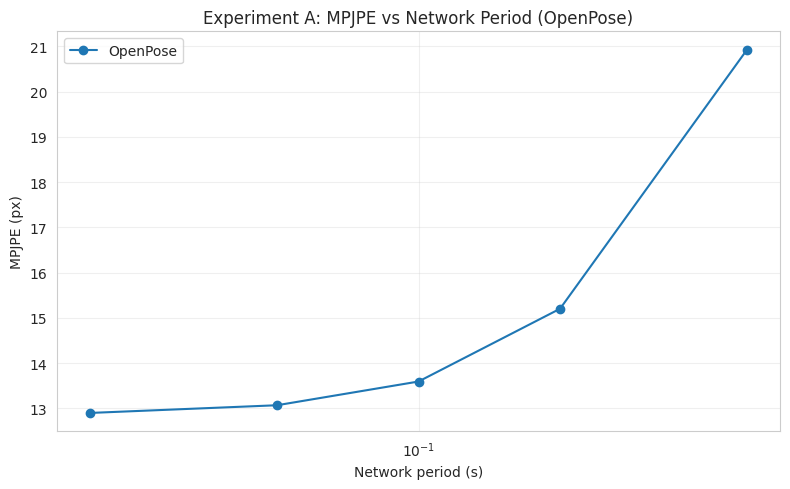

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/mpjpe_vs_network_period_sequence_averaged.png


In [ ]:
plt.figure(figsize=(8, 5))
for method in METHODS:
    d = agg_mpjpe[agg_mpjpe['method'] == method].sort_values('network_period_s')
    if len(d) == 0:
        continue

    plt.plot(d['network_period_s'], d['mpjpe_px_mean'], marker='o', label=method)
    plt.fill_between(
        d['network_period_s'],
        d['mpjpe_px_mean'],
        d['mpjpe_px_mean'],
        alpha=0.2
    )

plt.xscale('log')
plt.xlabel('Network period (s)')
plt.ylabel('MPJPE (px)')
plt.title('Experiment A: MPJPE vs Network Period (OpenPose)')
plt.grid(True, alpha=0.3)
plt.legend()

plot_path = PLOTS_DIR / 'mpjpe_vs_network_period_sequence_averaged.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

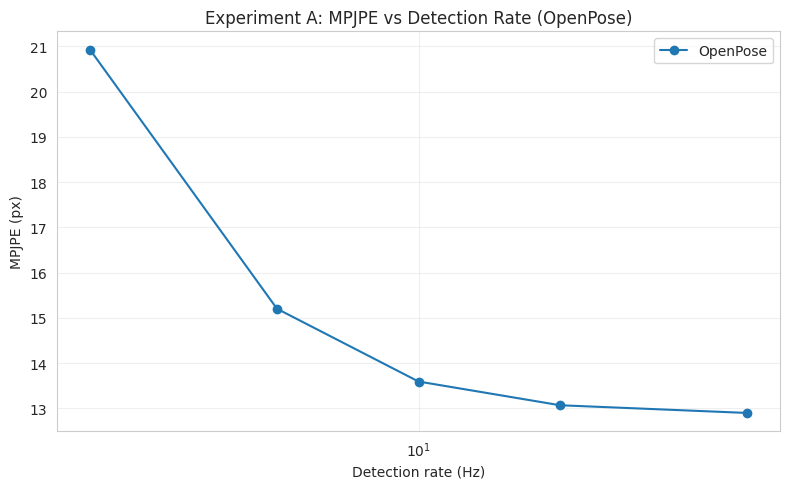

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/mpjpe_vs_detection_rate_sequence_averaged.png


In [ ]:
plt.figure(figsize=(8, 5))
for method in METHODS:
    d = agg_mpjpe[agg_mpjpe['method'] == method].sort_values('detection_rate_hz')
    if len(d) == 0:
        continue

    plt.plot(d['detection_rate_hz'], d['mpjpe_px_mean'], marker='o', label=method)
    plt.fill_between(
        d['detection_rate_hz'],
        d['mpjpe_px_mean'],
        d['mpjpe_px_mean'],
        alpha=0.2
    )

plt.xscale('log')
plt.xlabel('Detection rate (Hz)')
plt.ylabel('MPJPE (px)')
plt.title('Experiment A: MPJPE vs Detection Rate (OpenPose)')
plt.grid(True, alpha=0.3)
plt.legend()

plot_path = PLOTS_DIR / 'mpjpe_vs_detection_rate_sequence_averaged.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

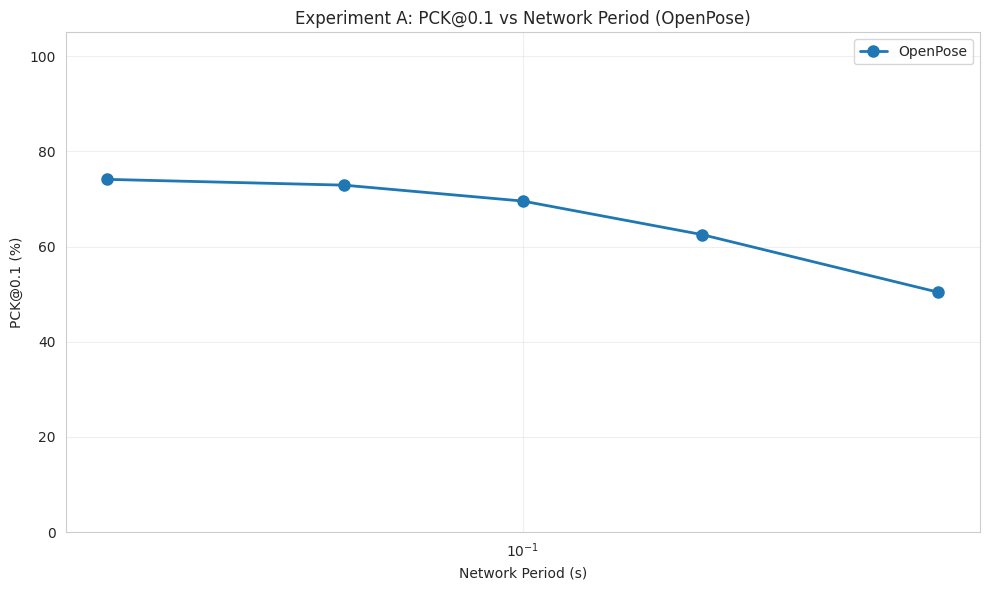

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/pck_vs_network_period_0.1_sequence_averaged.png


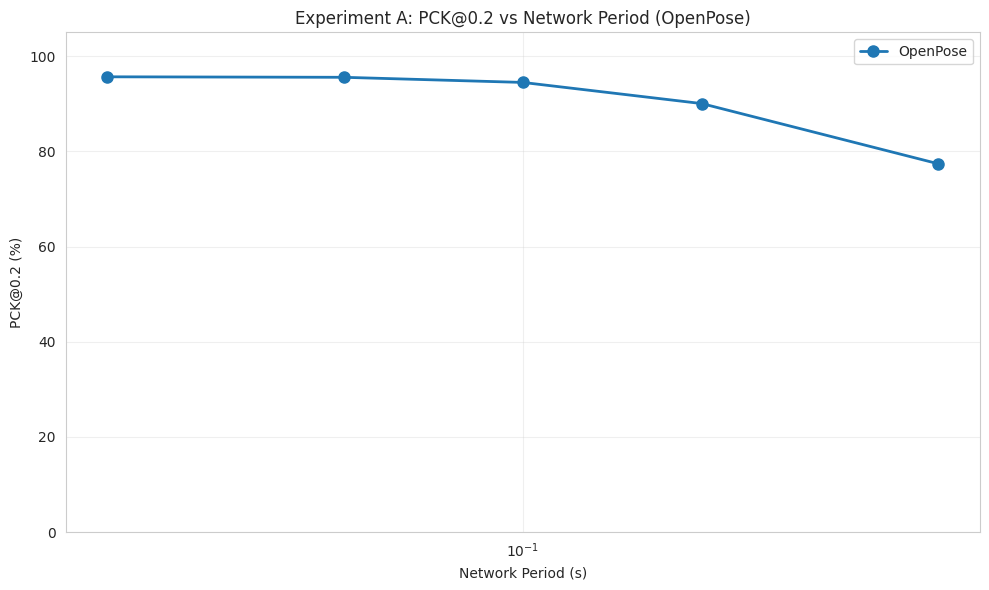

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/pck_vs_network_period_0.2_sequence_averaged.png


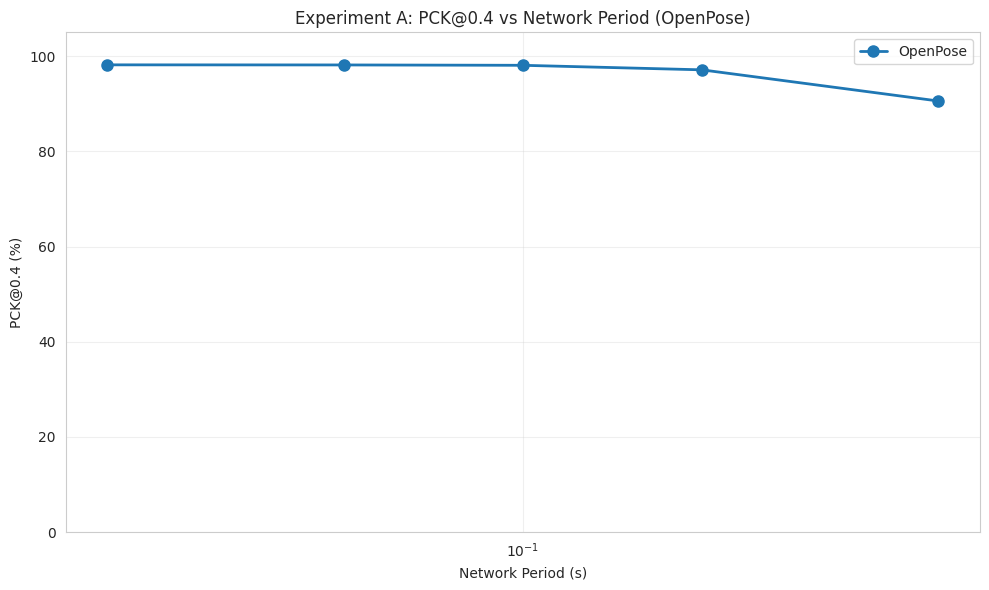

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/pck_vs_network_period_0.4_sequence_averaged.png


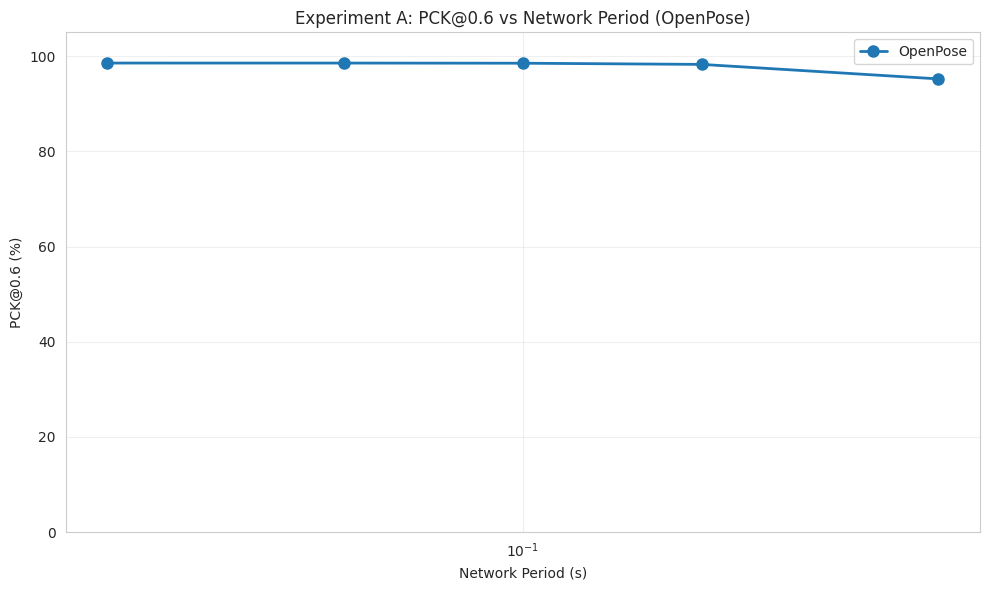

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/pck_vs_network_period_0.6_sequence_averaged.png


In [ ]:
for th in pck_thresholds:
    fig, ax = plt.subplots(figsize=(10, 6))
    col_mean = f'pck_{th:.1f}_mean'

    for method in METHODS:
        d = agg_pck[agg_pck['method'] == method].sort_values('network_period_s')
        if len(d) == 0:
            continue

        ax.plot(d['network_period_s'], d[col_mean], marker='o', linewidth=2, markersize=8, label=method)
        ax.fill_between(
            d['network_period_s'],
            d[col_mean],
            d[col_mean],
            alpha=0.2
        )

    ax.set_xscale('log')
    ax.set_xlabel('Network Period (s)')
    ax.set_ylabel(f'PCK@{th} (%)')
    ax.set_title(f'Experiment A: PCK@{th} vs Network Period (OpenPose)')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3)
    ax.legend()

    plot_path = PLOTS_DIR / f'pck_vs_network_period_{th:.1f}_sequence_averaged.png'
    plt.tight_layout()
    plt.savefig(plot_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)

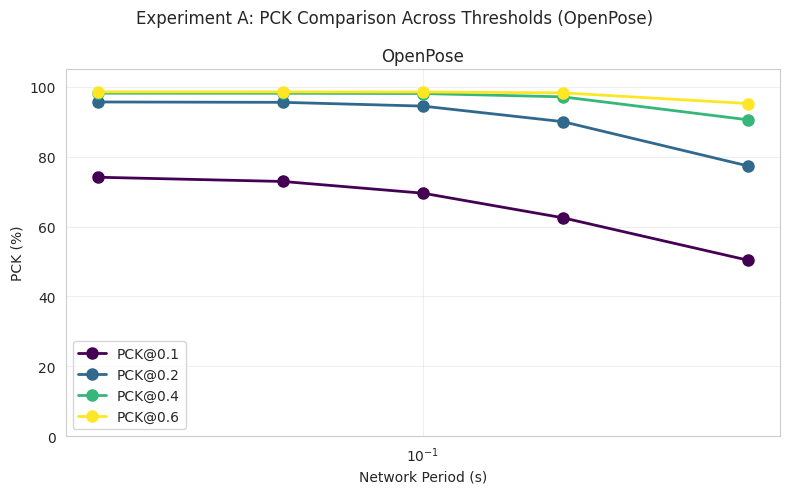

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/pck_comparison_all_thresholds_sequence_averaged.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
d = agg_pck[agg_pck['method'] == 'OpenPose'].sort_values('network_period_s')
colors = plt.cm.viridis(np.linspace(0, 1, len(pck_thresholds)))

for th_idx, th in enumerate(pck_thresholds):
    col_name = f'pck_{th:.1f}_mean'
    ax.plot(
        d['network_period_s'],
        d[col_name],
        marker='o',
        linewidth=2,
        markersize=8,
        color=colors[th_idx],
        label=f'PCK@{th}'
    )

ax.set_xscale('log')
ax.set_xlabel('Network Period (s)')
ax.set_ylabel('PCK (%)')
ax.set_title('OpenPose')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle('Experiment A: PCK Comparison Across Thresholds (OpenPose)')
plt.tight_layout()

plot_path = PLOTS_DIR / 'pck_comparison_all_thresholds_sequence_averaged.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

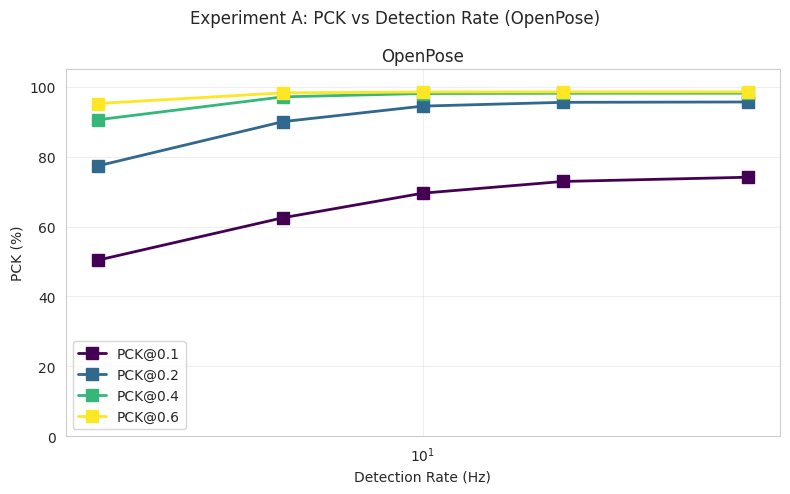

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/pck_vs_detection_rate_sequence_averaged.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
d = agg_pck[agg_pck['method'] == 'OpenPose'].sort_values('detection_rate_hz')
colors = plt.cm.viridis(np.linspace(0, 1, len(pck_thresholds)))

for th_idx, th in enumerate(pck_thresholds):
    col_name = f'pck_{th:.1f}_mean'
    ax.plot(
        d['detection_rate_hz'],
        d[col_name],
        marker='s',
        linewidth=2,
        markersize=8,
        color=colors[th_idx],
        label=f'PCK@{th}'
    )

ax.set_xscale('log')
ax.set_xlabel('Detection Rate (Hz)')
ax.set_ylabel('PCK (%)')
ax.set_title('OpenPose')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle('Experiment A: PCK vs Detection Rate (OpenPose)')
plt.tight_layout()

plot_path = PLOTS_DIR / 'pck_vs_detection_rate_sequence_averaged.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

,network_period_s,detection_rate_hz,method,mpjpe_px_mean,mpjpe_px_std,pck_0.1_mean,pck_0.2_mean,pck_0.4_mean,pck_0.6_mean
0,0.02,50.0,OpenPose,12.898503,4.695130,74.109269,95.656652,98.169301,98.547258
1,0.05,20.0,OpenPose,13.068707,4.752754,72.897798,95.553169,98.148198,98.543824
2,0.10,10.0,OpenPose,13.592827,5.017001,69.550770,94.474981,98.073978,98.512606
3,0.20,5.0,OpenPose,15.200522,5.794697,62.515036,90.030954,97.122033,98.263122
4,0.50,2.0,OpenPose,20.927887,10.015431,50.388180,77.376499,90.571124,95.215999


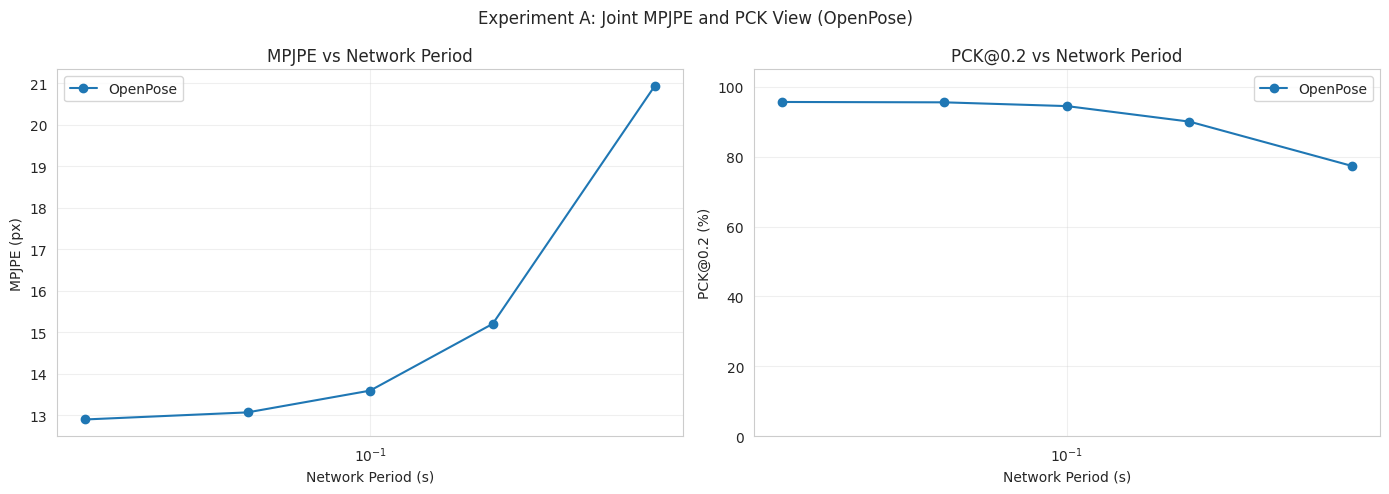

Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots/combined_mpjpe_pck_0.200_vs_network_period_sequence_averaged.png


In [ ]:
primary_pck_threshold = 0.2
primary_col = f'pck_{primary_pck_threshold:.1f}_mean'

compact_cols = [
    'network_period_s',
    'detection_rate_hz',
    'method',
    'mpjpe_px_mean',
    'mpjpe_px_std'
] + [f'pck_{th:.1f}_mean' for th in pck_thresholds]

compact_combined = df_combined[compact_cols].copy()
display(compact_combined)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
d = df_combined[df_combined['method'] == 'OpenPose'].sort_values('network_period_s')

axes[0].plot(d['network_period_s'], d['mpjpe_px_mean'], marker='o', label='OpenPose')
axes[0].fill_between(
    d['network_period_s'],
    d['mpjpe_px_mean'],
    d['mpjpe_px_mean'],
    alpha=0.2
)

axes[1].plot(d['network_period_s'], d[primary_col], marker='o', label='OpenPose')
axes[1].fill_between(
    d['network_period_s'],
    d[primary_col],
    d[primary_col],
    alpha=0.2
)

axes[0].set_xscale('log')
axes[1].set_xscale('log')

axes[0].set_xlabel('Network Period (s)')
axes[0].set_ylabel('MPJPE (px)')
axes[0].set_title('MPJPE vs Network Period')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('Network Period (s)')
axes[1].set_ylabel(f'PCK@{primary_pck_threshold} (%)')
axes[1].set_title(f'PCK@{primary_pck_threshold} vs Network Period')
axes[1].set_ylim([0, 105])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Experiment A: Joint MPJPE and PCK View (OpenPose)')
plt.tight_layout()

plot_path = PLOTS_DIR / f'combined_mpjpe_pck_{primary_pck_threshold:.3f}_vs_network_period_sequence_averaged.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

In [ ]:
per_joint_cols = [f'mpjpe_{joint}' for joint in joint_names]

agg_mpjpe_joints = (
    df_seq.groupby(['network_period_s', 'detection_rate_hz', 'method'], as_index=False)[per_joint_cols]
    .mean()
    .sort_values(['network_period_s', 'method'])
    .reset_index(drop=True)
)

display(agg_mpjpe_joints)

per_joint_path = SUMMARY_DIR / 'mpjpe_per_joint_sequence_averaged.csv'
agg_mpjpe_joints.to_csv(per_joint_path, index=False)
print('Saved:', per_joint_path)

,network_period_s,detection_rate_hz,method,mpjpe_head,mpjpe_shoulder_right,mpjpe_shoulder_left,mpjpe_elbow_right,mpjpe_elbow_left,mpjpe_hip_left,mpjpe_hip_right,mpjpe_wrist_right,mpjpe_wrist_left,mpjpe_knee_right,mpjpe_knee_left,mpjpe_ankle_right,mpjpe_ankle_left
0,0.02,50.0,OpenPose,50.001534,6.435223,6.195962,7.963164,10.615110,11.232199,11.830878,18.077800,13.506460,5.137466,8.139681,8.114603,10.430459
1,0.05,20.0,OpenPose,49.675044,6.660905,6.320229,8.282888,10.812196,11.317486,11.860242,18.513670,13.956355,5.459630,8.355991,8.210389,10.468168
2,0.10,10.0,OpenPose,49.674743,7.261344,6.757700,9.011651,11.367799,11.581440,12.089767,19.567144,14.874990,6.112484,8.875815,8.815011,10.716860
3,0.20,5.0,OpenPose,50.435715,9.008588,8.142425,11.688907,12.628026,12.550329,12.929093,22.929747,16.558685,7.686756,10.361487,10.145427,12.541597
4,0.50,2.0,OpenPose,54.395750,15.436982,13.614886,20.071508,19.025179,16.057444,17.088152,32.342337,25.161968,13.051149,14.588819,15.338370,15.889984


Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/mpjpe_per_joint_sequence_averaged.csv


In [ ]:
rows_joint_pck = []
for period_s in sorted(df_seq['network_period_s'].unique()):
    for method in METHODS:
        subset = df_seq[(df_seq['network_period_s'] == period_s) & (df_seq['method'] == method)]
        if len(subset) == 0:
            continue

        row = {
            'network_period_s': period_s,
            'detection_rate_hz': 1.0 / period_s,
            'method': method
        }

        for th in pck_thresholds:
            for joint in joint_names:
                col = f'pck_{th:.1f}_{joint}'
                row[f'{col}_mean'] = float(subset[col].mean())

        rows_joint_pck.append(row)

agg_pck_joints = pd.DataFrame(rows_joint_pck).sort_values(['network_period_s', 'method']).reset_index(drop=True)
display(agg_pck_joints)

per_joint_pck_path = SUMMARY_DIR / 'pck_per_joint_sequence_averaged.csv'
agg_pck_joints.to_csv(per_joint_pck_path, index=False)
print('Saved:', per_joint_pck_path)

,network_period_s,detection_rate_hz,method,pck_0.1_head_mean,pck_0.1_shoulder_right_mean,pck_0.1_shoulder_left_mean,pck_0.1_elbow_right_mean,pck_0.1_elbow_left_mean,pck_0.1_hip_left_mean,pck_0.1_hip_right_mean,pck_0.1_wrist_right_mean,pck_0.1_wrist_left_mean,pck_0.1_knee_right_mean,pck_0.1_knee_left_mean,pck_0.1_ankle_right_mean,pck_0.1_ankle_left_mean,pck_0.2_head_mean,pck_0.2_shoulder_right_mean,pck_0.2_shoulder_left_mean,pck_0.2_elbow_right_mean,pck_0.2_elbow_left_mean,pck_0.2_hip_left_mean,pck_0.2_hip_right_mean,pck_0.2_wrist_right_mean,pck_0.2_wrist_left_mean,pck_0.2_knee_right_mean,pck_0.2_knee_left_mean,pck_0.2_ankle_right_mean,pck_0.2_ankle_left_mean,pck_0.4_head_mean,pck_0.4_shoulder_right_mean,pck_0.4_shoulder_left_mean,pck_0.4_elbow_right_mean,pck_0.4_elbow_left_mean,pck_0.4_hip_left_mean,pck_0.4_hip_right_mean,pck_0.4_wrist_right_mean,pck_0.4_wrist_left_mean,pck_0.4_knee_right_mean,pck_0.4_knee_left_mean,pck_0.4_ankle_right_mean,pck_0.4_ankle_left_mean,pck_0.6_head_mean,pck_0.6_shoulder_right_mean,pck_0.6_shoulder_left_mean,pck_0.6_elbow_right_mean,pck_0.6_elbow_left_mean,pck_0.6_hip_left_mean,pck_0.6_hip_right_mean,pck_0.6_wrist_right_mean,pck_0.6_wrist_left_mean,pck_0.6_knee_right_mean,pck_0.6_knee_left_mean,pck_0.6_ankle_right_mean,pck_0.6_ankle_left_mean
0,0.02,50.0,OpenPose,26.801775,87.829801,88.954457,87.087854,81.042393,46.167001,42.206947,87.968007,88.794523,95.118675,83.031294,85.520444,62.897334,85.794675,96.394394,97.646591,96.607727,94.303203,96.208513,95.065637,94.743780,95.736900,99.414454,98.406265,97.068764,96.145576,91.275668,98.902134,99.242910,99.125474,98.062251,98.286693,99.019579,96.509516,97.107054,99.809641,99.730102,99.483767,99.646128,91.397598,99.688990,99.656104,99.380595,98.643963,99.314959,99.682031,96.866446,97.307405,99.898502,99.871292,99.650761,99.755712
1,0.05,20.0,OpenPose,27.327979,86.624331,87.932851,85.443886,79.696695,45.780899,42.232046,85.246796,86.399637,92.361304,80.589600,84.937332,63.098015,86.516027,96.289496,97.476113,96.440855,94.188376,96.040827,95.233530,94.431108,95.447540,99.210167,98.212838,96.848468,95.855847,91.294100,98.839146,99.240310,99.081149,97.995737,98.275502,99.034737,96.445955,97.078914,99.811709,99.722375,99.478808,99.628135,91.451826,99.632316,99.624971,99.382909,98.646932,99.302039,99.693294,96.835709,97.297735,99.893371,99.896906,99.661778,99.749928
2,0.10,10.0,OpenPose,28.341027,82.896829,85.259756,79.822178,75.897063,44.142211,41.516024,77.516827,81.024712,88.133135,75.904550,81.980317,61.725373,85.904570,95.451190,96.637233,95.339887,93.712733,95.222715,94.450800,92.556576,94.084558,97.987097,97.271864,95.234406,94.321122,91.095436,98.855981,99.195008,98.905483,97.831685,98.256460,99.058712,96.341646,96.953125,99.815330,99.723130,99.344341,99.585378,91.383728,99.536056,99.550568,99.384720,98.588343,99.348488,99.652328,96.814212,97.211060,99.897366,99.881402,99.646436,99.769180
3,0.20,5.0,OpenPose,28.171563,74.450085,77.559452,68.013741,66.641390,40.425093,39.426537,63.265720,69.117747,80.762757,68.357598,77.653757,58.850031,83.231896,90.800948,93.535921,89.210269,90.310807,91.574475,90.251988,84.278100,88.340579,93.882474,93.309199,91.403781,90.271963,90.415830,98.089747,98.682978,97.637044,97.277981,97.988040,98.694713,94.515473,96.097121,98.722427,98.981472,97.580020,97.903577,91.067827,99.336867,99.356165,99.050819,98.476031,99.261754,99.657721,96.374955,97.173878,99.708091,99.687651,99.089292,99.179527
4,0.50,2.0,OpenPose,22.856079,59.482782,62.535588,49.152834,49.788495,33.900538,34.479786,43.037817,49.888718,68.949120,56.197708,70.954418,53.822452,70.630760,78.104690,81.145975,71.651597,75.542411,80.427552,79.740319,64.541288,71.021406,83.561907,81.791109,83.830106,83.905371,85.215394,90.410808,93.403862,88.296501,91.884464,93.295262,92.640280,83.256474,87.588154,93.014580,93.825816,92.276658,92.316350,89.131173,95.679673,97.529417,94.231060,96.748773,97.909635,97.207280,90.821953,93.574202,96.604458,97.405671,95.238406,95.726296


Saved: /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary/pck_per_joint_sequence_averaged.csv


In [ ]:
print('=' * 80)
print('EXPERIMENT A — OPENPOSE COMBINED MPJPE AND PCK SUMMARY (SEQUENCE-AVERAGED)')
print('=' * 80)

for method in METHODS:
    d = df_combined[df_combined['method'] == method]
    if len(d) == 0:
        continue

    print(f'\n{method}')
    print('-' * 80)
    print(f"Mean MPJPE across tested periods: {d['mpjpe_px_mean'].mean():.3f} px")
    print(f"Best MPJPE: {d['mpjpe_px_mean'].min():.3f} px")
    print(f"Worst MPJPE: {d['mpjpe_px_mean'].max():.3f} px")

    for th in pck_thresholds:
        col = f'pck_{th:.1f}_mean'
        print(f"PCK@{th}: mean={d[col].mean():.2f}% | min={d[col].min():.2f}% | max={d[col].max():.2f}%")

print('\nSaved outputs:')
print('  Summary CSVs ->', SUMMARY_DIR)
print('  Plots        ->', PLOTS_DIR)
print('=' * 80)

EXPERIMENT A — OPENPOSE COMBINED MPJPE AND PCK SUMMARY (SEQUENCE-AVERAGED)

OpenPose
--------------------------------------------------------------------------------
Mean MPJPE across tested periods: 15.138 px
Best MPJPE: 12.899 px
Worst MPJPE: 20.928 px
PCK@0.1: mean=65.89% | min=50.39% | max=74.11%
PCK@0.2: mean=90.62% | min=77.38% | max=95.66%
PCK@0.4: mean=96.42% | min=90.57% | max=98.17%
PCK@0.6: mean=97.82% | min=95.22% | max=98.55%

Saved outputs:
  Summary CSVs -> /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/results/summary
  Plots        -> /home/moveEnetFlow/experiments/OP_expA_accuracy_vs_network_period/op_expA_combined_mpjpe_pck_analysis/plots
